In [1]:
import os
import numpy as np
import torch
import pickle

from sensorium.utility import get_data, set_random_seed
from sensorium.utility.scores import get_correlations

from utils import load_model_from_config, get_knn_curve, get_ari_curve, whiten, get_cka, get_rsa, get_metrics
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
cache_file = 'data/new_retop_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        white_readouts = pickle.load(f)
else:
    white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=False, n_subsample=100, as_dict=True) 
        for model in new_retop_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(white_readouts, f)

In [4]:
normed_readouts = [
    {k: r / r.norm(dim=1, keepdim=True) for k, r in readouts.items()}
    for readouts in white_readouts
]

## PCA

In [23]:
# global PCA

model_nr = 0
grids = {}
colors = {}

X = torch.cat(list(normed_readouts[model_nr].values()))
Xc = X - X.mean(0)

U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)
explained_var_ratio = (S**2) / (S**2).sum()

k = 3
Z = Xc @ Vt[:k].T

def robust_normalize(Z, low=1, high=99):
    lo = torch.quantile(Z, low / 100, dim=0)
    hi = torch.quantile(Z, high / 100, dim=0)
    Zc = (Z - lo) / (hi - lo)
    return Zc.clamp(0, 1)

color = robust_normalize(Z)

offset = 0
for key in data_keys:
    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates

    depths = grid[:, 2]
    unique = np.unique(depths)
    idcs_by_layer = [np.where(depths == d)[0] for d in unique]
    cords_by_layer = [grid[idcs, :2] for idcs in idcs_by_layer]

    color_by_layer = [color[idcs + offset] for idcs in idcs_by_layer]
    
    grids[key] = cords_by_layer
    colors[key] = color_by_layer
    
    offset += grid.shape[0]

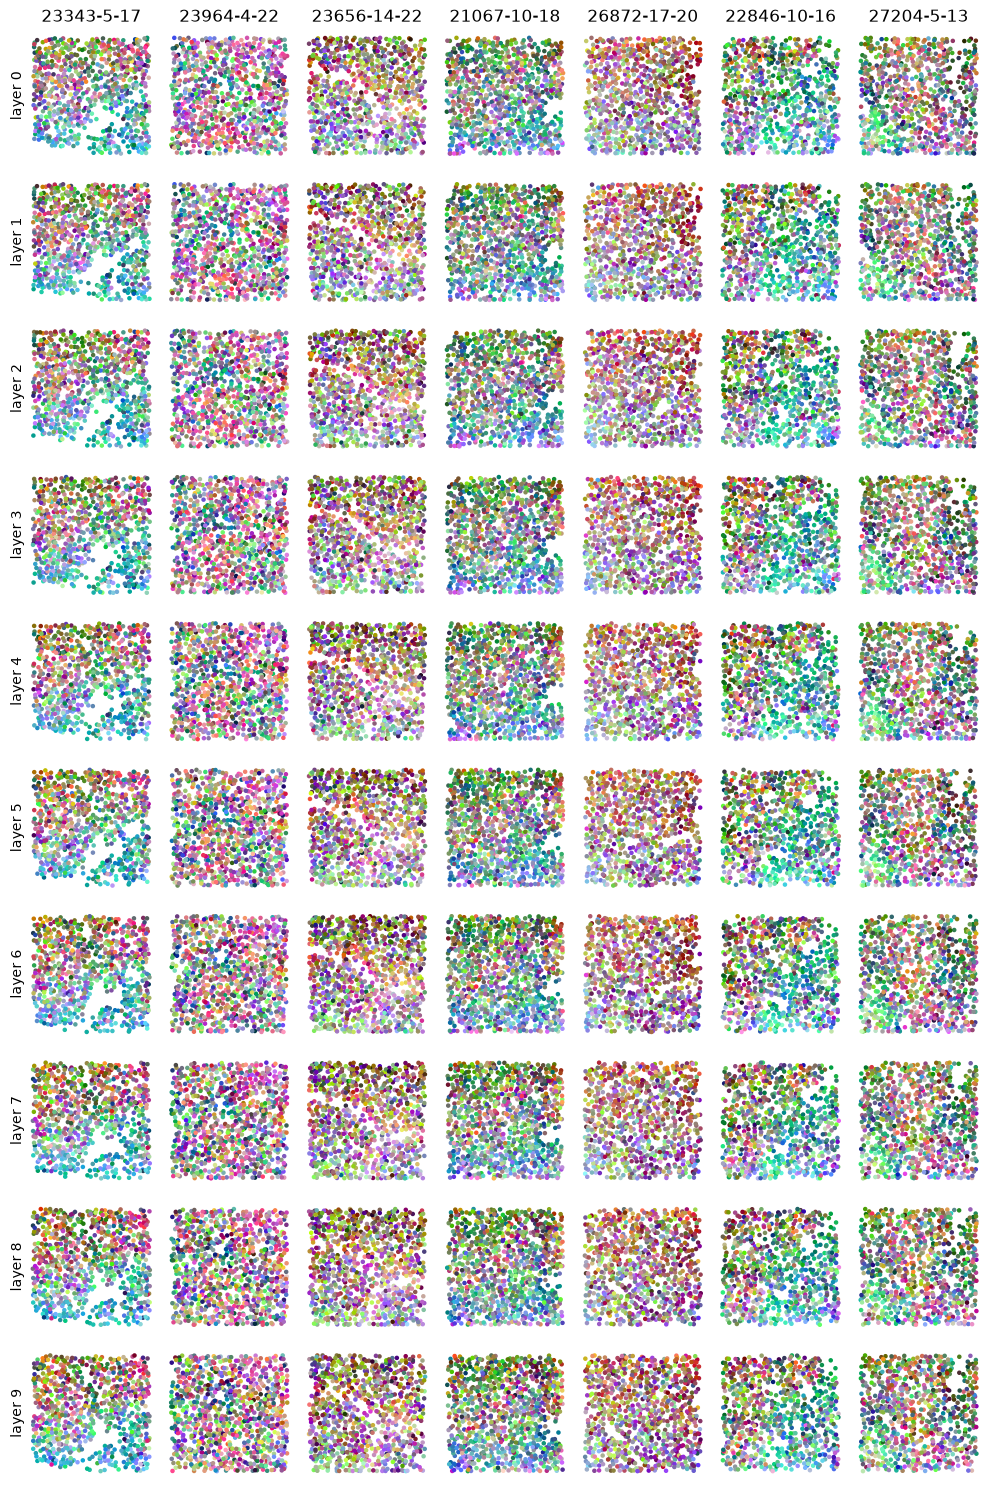

In [24]:
fig, axs = plt.subplots(len(grids[data_keys[0]]), len(grids), figsize=(10, 15))

for i, key in enumerate(data_keys):
    for j, (cords, color) in enumerate(zip(grids[key], colors[key])):
        ax = axs[j, i]
        ax.scatter(cords[:, 0], cords[:, 1], c=color, s=5)
        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        for spines in ax.spines.values():
            spines.set_visible(False)

        if i == 0:
            ax.set_ylabel(f'layer {j}')
        if j == 0:
            ax.set_title(key)
            

plt.tight_layout()
plt.show()

## UMAP

In [25]:
# global UMAP (3D, scales fine to 50k points)
import umap

model_nr = 0
grids = {}
colors = {}

X = torch.cat(list(normed_readouts[model_nr].values()))
Xc = X - X.mean(0)
Xc_np = Xc.numpy()

k = 3
reducer = umap.UMAP(
    n_components=k,
    n_neighbors=15,   # lower = more local focus, higher = more global
    min_dist=0.1,
    # random_state=0,
)
Z = torch.from_numpy(reducer.fit_transform(Xc_np))

def robust_normalize(Z, low=1, high=99):
    lo = torch.quantile(Z, low / 100, dim=0)
    hi = torch.quantile(Z, high / 100, dim=0)
    Zc = (Z - lo) / (hi - lo)
    return Zc.clamp(0, 1)

color = robust_normalize(Z)
# color = (Z - Z.amin(0)) / (Z.amax(0) - Z.amin(0))

offset = 0
for key in data_keys:
    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates

    depths = grid[:, 2]
    unique = np.unique(depths)
    idcs_by_layer = [np.where(depths == d)[0] for d in unique]
    cords_by_layer = [grid[idcs, :2] for idcs in idcs_by_layer]

    color_by_layer = [color[idcs + offset] for idcs in idcs_by_layer]
    grids[key] = cords_by_layer
    colors[key] = color_by_layer
    offset += grid.shape[0]

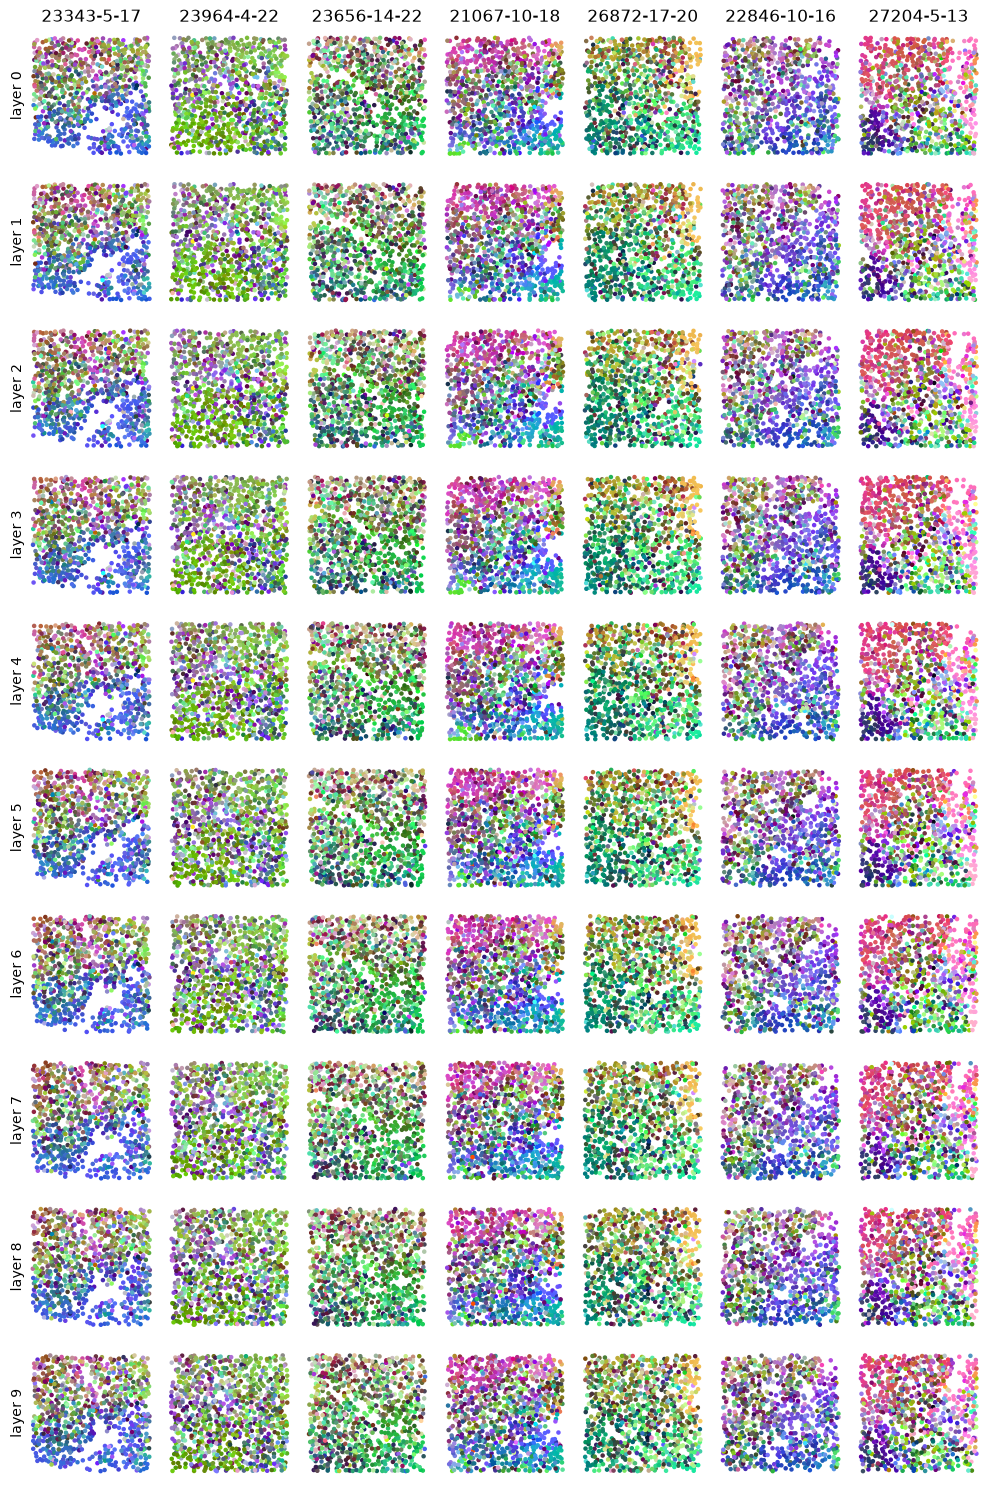

In [26]:
fig, axs = plt.subplots(len(grids[data_keys[0]]), len(grids), figsize=(10, 15))

for i, key in enumerate(data_keys):
    for j, (cords, color) in enumerate(zip(grids[key], colors[key])):
        ax = axs[j, i]
        ax.scatter(cords[:, 0], cords[:, 1], c=color, s=5)
        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        for spines in ax.spines.values():
            spines.set_visible(False)

        if i == 0:
            ax.set_ylabel(f'layer {j}')
        if j == 0:
            ax.set_title(key)
            

plt.tight_layout()
plt.show()